In [1]:
# ============================================================
# NOTEBOOK 02 - MODELO PREDITIVO DE NPS
# NPS Preditivo - Tech Challenge Fase 1 - FIAP PosTech
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             roc_auc_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print("Bibliotecas carregadas com sucesso!")
print(f"\nVersões principais:")
import sklearn; print(f"  scikit-learn: {sklearn.__version__}")
import xgboost; print(f"  xgboost:      {xgboost.__version__}")
print(f"  shap:         {shap.__version__}")

Bibliotecas carregadas com sucesso!

Versões principais:
  scikit-learn: 1.8.0
  xgboost:      3.2.0
  shap:         0.51.0


In [2]:
# ============================================================
# SEÇÃO 2 - CARREGAMENTO E PRÉ-PROCESSAMENTO
# ============================================================

# --- Carregando os dados ---
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv',
                 sep=None, engine='python')

print(f"Base carregada: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# --- Criando a target categórica ---
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

# --- Removendo variáveis que não devem entrar no modelo ---
colunas_remover = ['customer_id', 'order_id',
                   'nps_score', 'csat_internal_score']

df_modelo = df.drop(columns=colunas_remover)

print(f"\nVariáveis removidas: {colunas_remover}")
print(f"Colunas restantes: {df_modelo.shape[1]}")

# --- Encoding da variável categórica (customer_region) ---
le_regiao = LabelEncoder()
df_modelo['customer_region'] = le_regiao.fit_transform(
    df_modelo['customer_region'])

print(f"\nEncoding de customer_region:")
for i, regiao in enumerate(le_regiao.classes_):
    print(f"  {regiao} → {i}")

# --- Encoding da target ---
le_target = LabelEncoder()
df_modelo['nps_categoria'] = le_target.fit_transform(
    df_modelo['nps_categoria'])

print(f"\nEncoding da target:")
for i, cat in enumerate(le_target.classes_):
    print(f"  {cat} → {i}")

# --- Separando features e target ---
X = df_modelo.drop(columns=['nps_categoria'])
y = df_modelo['nps_categoria']

print(f"\nFeatures (X): {X.shape[1]} variáveis")
print(f"Target  (y): {y.shape[0]:,} registros")
print(f"\nDistribuição da target:")
for i, cat in enumerate(le_target.classes_):
    n = (y == i).sum()
    print(f"  {cat} ({i}): {n:,} ({n/len(y)*100:.1f}%)")

Base carregada: 2,500 linhas × 19 colunas

Variáveis removidas: ['customer_id', 'order_id', 'nps_score', 'csat_internal_score']
Colunas restantes: 16

Encoding de customer_region:
  Centro-Oeste → 0
  Nordeste → 1
  Norte → 2
  Sudeste → 3
  Sul → 4

Encoding da target:
  Detrator → 0
  Neutro → 1
  Promotor → 2

Features (X): 15 variáveis
Target  (y): 2,500 registros

Distribuição da target:
  Detrator (0): 1,851 (74.0%)
  Neutro (1): 448 (17.9%)
  Promotor (2): 201 (8.0%)


In [4]:
# ============================================================
# SEÇÃO 3 - SEPARAÇÃO TREINO / TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # mantém proporção das classes
)

print("=== SEPARAÇÃO TREINO / TESTE ===\n")
print(f"Total de registros:  {len(X):,}")
print(f"Treino (70%):        {len(X_train):,} registros")
print(f"Teste  (30%):        {len(X_test):,} registros")

print(f"\n=== PROPORÇÃO DAS CLASSES ===")
print(f"\n{'Classe':<12} {'Treino':>10} {'Teste':>10}")
print("-" * 34)
for i, cat in enumerate(le_target.classes_):
    n_train = (y_train == i).sum()
    n_test  = (y_test  == i).sum()
    pct_train = n_train / len(y_train) * 100
    pct_test  = n_test  / len(y_test)  * 100
    print(f"{cat:<12} {n_train:>5} ({pct_train:.1f}%)  "
          f"{n_test:>4} ({pct_test:.1f}%)")

print(f"\nProporção mantida entre treino e teste (stratify=y)")
print(f"random_state=42 garante reprodutibilidade")

=== SEPARAÇÃO TREINO / TESTE ===

Total de registros:  2,500
Treino (70%):        1,750 registros
Teste  (30%):        750 registros

=== PROPORÇÃO DAS CLASSES ===

Classe           Treino      Teste
----------------------------------
Detrator      1296 (74.1%)   555 (74.0%)
Neutro         313 (17.9%)   135 (18.0%)
Promotor       141 (8.1%)    60 (8.0%)

Proporção mantida entre treino e teste (stratify=y)
random_state=42 garante reprodutibilidade


=== BASELINE — DUMMY CLASSIFIER ===
Estratégia: sempre chuta a classe mais frequente (Detrator)

              precision    recall  f1-score   support

    Detrator       0.74      1.00      0.85       555
      Neutro       0.00      0.00      0.00       135
    Promotor       0.00      0.00      0.00        60

    accuracy                           0.74       750
   macro avg       0.25      0.33      0.28       750
weighted avg       0.55      0.74      0.63       750

F1-Score (weighted): 0.6294


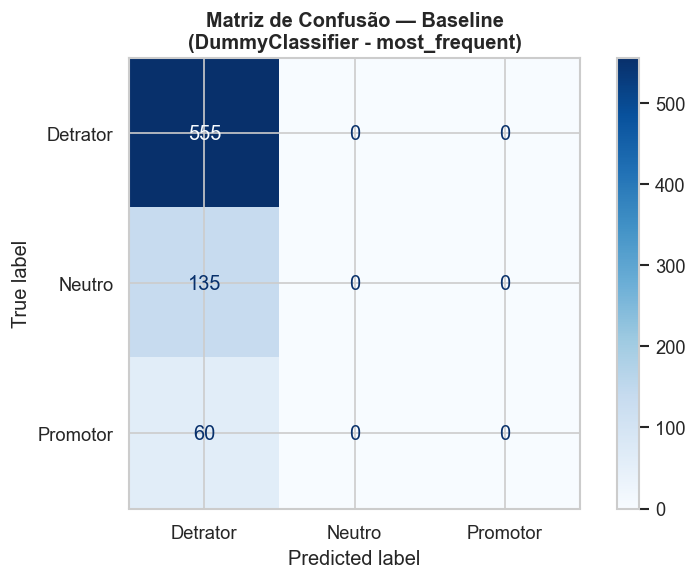


 Baseline nunca prevê Neutro ou Promotor
 Qualquer modelo real precisa superar esse resultado


In [7]:
# ============================================================
# SEÇÃO 4 - MODELO BASELINE (DUMMY CLASSIFIER)
# ============================================================

# Treinando o modelo baseline
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== BASELINE — DUMMY CLASSIFIER ===")
print("Estratégia: sempre chuta a classe mais frequente (Detrator)\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_baseline,
    target_names=le_target.classes_))

# F1 Score geral
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')
print(f"F1-Score (weighted): {f1_baseline:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — Baseline\n'
             '(DummyClassifier - most_frequent)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_matriz_baseline.png', bbox_inches='tight')
plt.show()

print("\n Baseline nunca prevê Neutro ou Promotor")
print(" Qualquer modelo real precisa superar esse resultado")

Treinando Random Forest...
(pode demorar alguns segundos)

=== RANDOM FOREST — RESULTADOS ===

              precision    recall  f1-score   support

    Detrator       0.84      0.98      0.91       555
      Neutro       0.76      0.23      0.35       135
    Promotor       0.94      1.00      0.97        60

    accuracy                           0.85       750
   macro avg       0.85      0.74      0.74       750
weighted avg       0.84      0.85      0.81       750

F1-Score (weighted): 0.8130
Melhoria vs Baseline: +0.1836


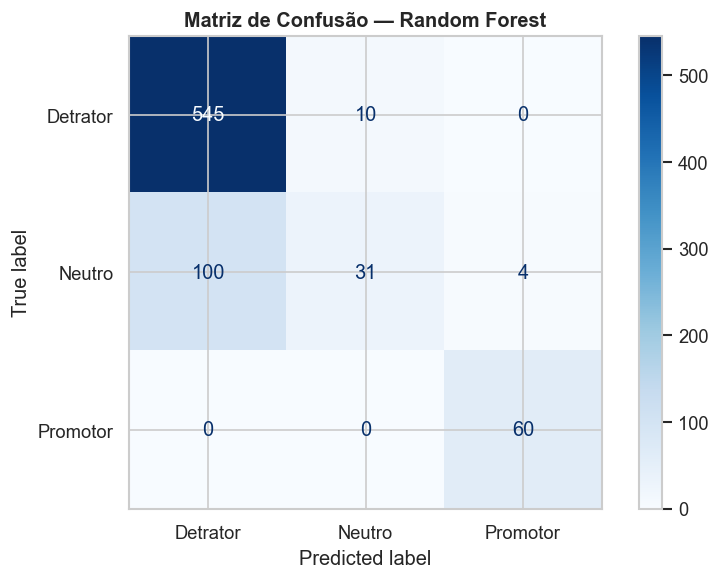

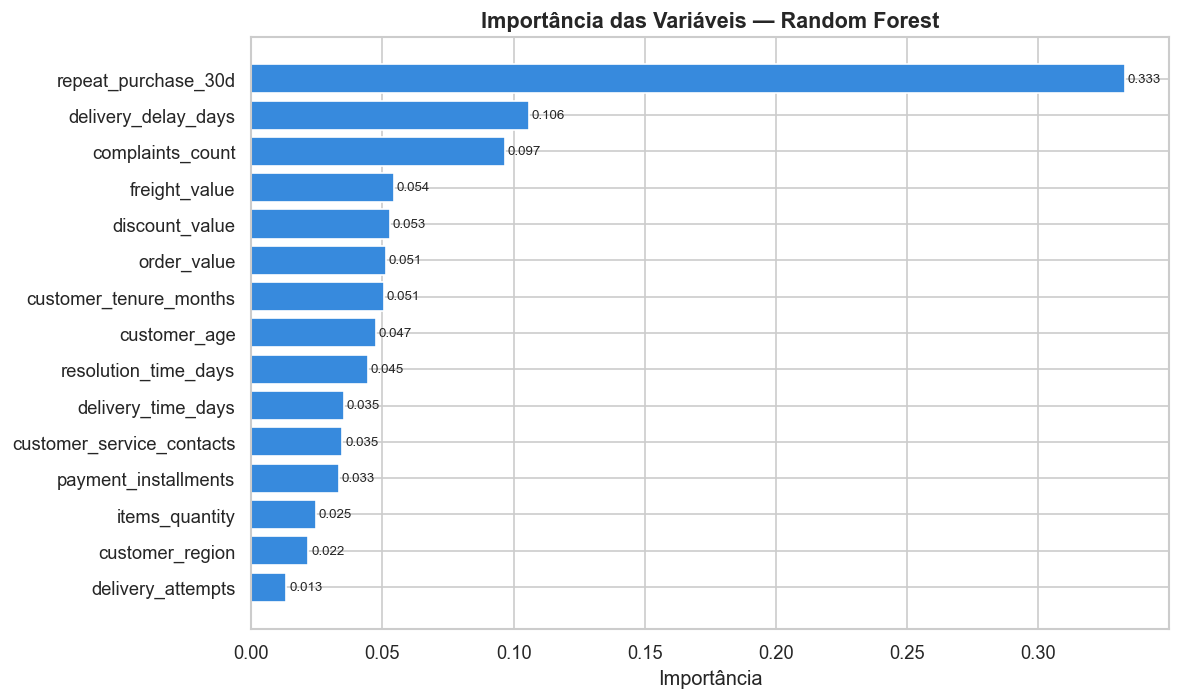

In [8]:
# ============================================================
# SEÇÃO 5 - RANDOM FOREST
# ============================================================

print("Treinando Random Forest...")
print("(pode demorar alguns segundos)\n")

# Treinando o modelo
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST — RESULTADOS ===\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_rf,
    target_names=le_target.classes_))

# F1 Score
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1-Score (weighted): {f1_rf:.4f}")
print(f"Melhoria vs Baseline: +{f1_rf - f1_baseline:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — Random Forest',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_matriz_random_forest.png',
            bbox_inches='tight')
plt.show()

# Feature importance
importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias['variavel'],
               importancias['importancia'],
               color='#378ADD', edgecolor='white')
ax.set_title('Importância das Variáveis — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
for bar, val in zip(bars, importancias['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance_rf.png',
            bbox_inches='tight')
plt.show()

=== PESOS DAS CLASSES (balanceamento) ===
  Detrator: 0.450
  Neutro: 1.864
  Promotor: 4.137

Treinando XGBoost...
(pode demorar alguns segundos)

=== XGBOOST — RESULTADOS ===

              precision    recall  f1-score   support

    Detrator       0.88      0.91      0.89       555
      Neutro       0.54      0.45      0.49       135
    Promotor       0.94      0.97      0.95        60

    accuracy                           0.83       750
   macro avg       0.78      0.78      0.78       750
weighted avg       0.82      0.83      0.82       750

F1-Score (weighted):      0.8249
Melhoria vs Baseline:    +0.1955
Melhoria vs Rand Forest: +0.0120


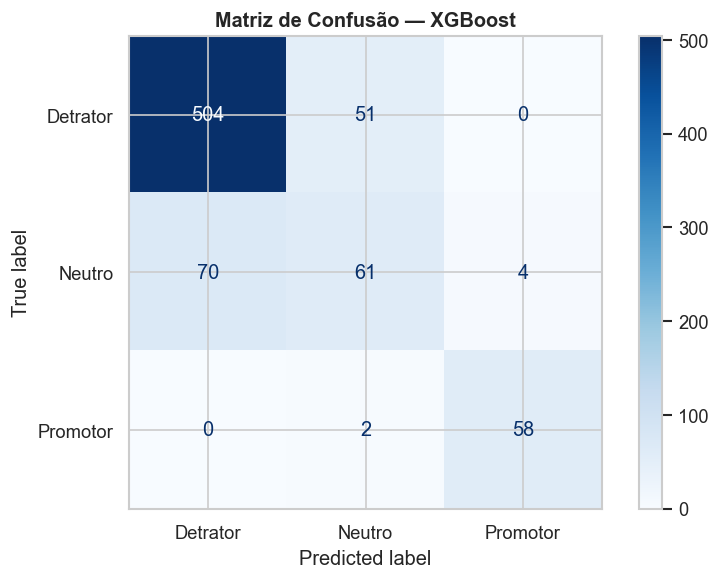

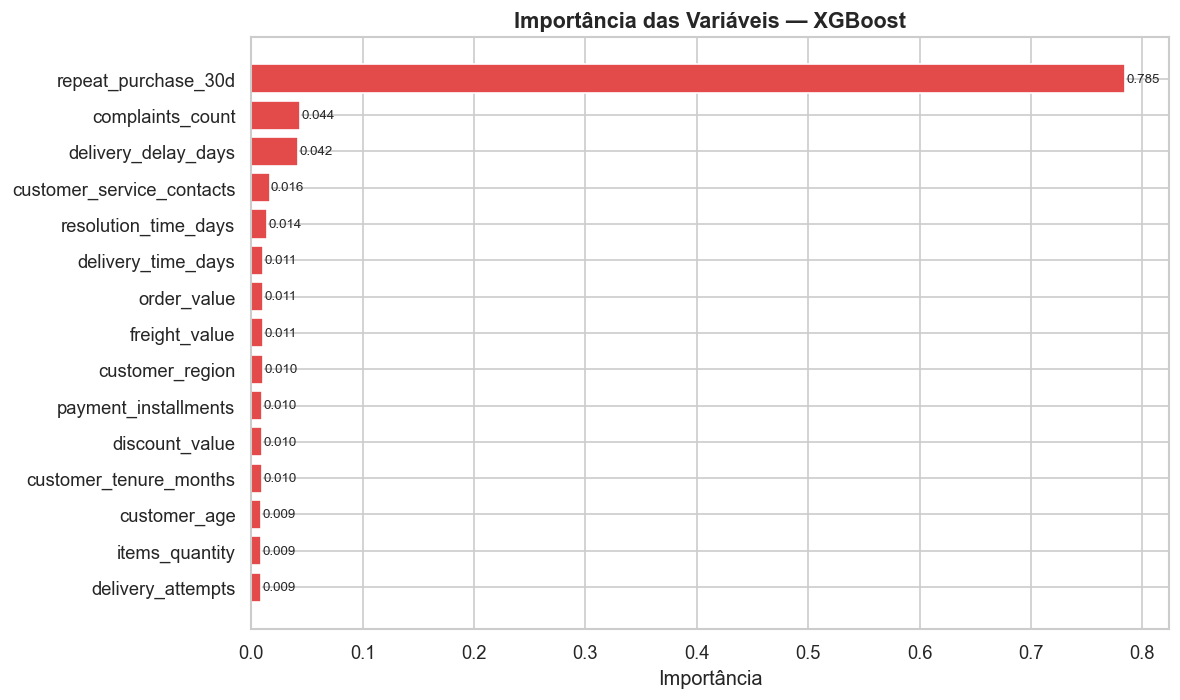

In [9]:
# ============================================================
# SEÇÃO 6 - XGBOOST
# ============================================================

# Calculando pesos para balancear as classes
contagem_classes = np.bincount(y_train)
peso_classes = len(y_train) / (len(contagem_classes) * contagem_classes)

print("=== PESOS DAS CLASSES (balanceamento) ===")
for i, cat in enumerate(le_target.classes_):
    print(f"  {cat}: {peso_classes[i]:.3f}")

# Criando vetor de pesos para cada amostra de treino
sample_weights = np.array([peso_classes[y] for y in y_train])

print("\nTreinando XGBoost...")
print("(pode demorar alguns segundos)\n")

# Treinando o modelo
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBOOST — RESULTADOS ===\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_xgb,
    target_names=le_target.classes_))

# F1 Score
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"F1-Score (weighted):      {f1_xgb:.4f}")
print(f"Melhoria vs Baseline:    +{f1_xgb - f1_baseline:.4f}")
print(f"Melhoria vs Rand Forest: +{f1_xgb - f1_rf:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — XGBoost',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/10_matriz_xgboost.png', bbox_inches='tight')
plt.show()

# Feature importance XGBoost
importancias_xgb = pd.DataFrame({
    'variavel': X.columns,
    'importancia': xgb.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias_xgb['variavel'],
               importancias_xgb['importancia'],
               color='#E24B4A', edgecolor='white')
ax.set_title('Importância das Variáveis — XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
for bar, val in zip(bars, importancias_xgb['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/11_feature_importance_xgb.png',
            bbox_inches='tight')
plt.show()